# RQ2: Profit Erosion Concentration & Customer Segmentation 

This notebook implements **Research Question 2 (RQ2)** of the Capstone project:

> **To what extent is profit erosion concentrated among a small subset of customers, and can customers be meaningfully segmented based on behavioral and erosion characteristics?**

## Analysis Phases

1. **Concentration Analysis** - Analyze profit erosion distribution among customers with returns
   - Pareto analysis (80/20 rule)
   - Lorenz curve and Gini coefficient
   - Bootstrap significance testing

2. **Customer Segmentation** - Cluster customers with returns into behavioral segments
   - K-means clustering on return customers only
   - Optimal k selection (elbow + silhouette)
   - Cluster profiling and interpretation

## Key Methodological Decision

**⚠️ CRITICAL**: This analysis focuses exclusively on **customers who made returns** (profit erosion > 0).

**Rationale**:
- Research question asks about concentration **among customers causing erosion**
- Including non-returners (85% of customers) would create trivial "returners vs non-returners" segments
- Goal is to identify **behavioral patterns within the return population**, not obvious classification

**Population**:
- Total customers: 79,935
- Customers with returns: 11,790 (14.7%)
- **Analysis population**: 11,790 customers

## 1. Setup and Imports

In [1]:
import json
import sys
import warnings
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('Cannot find project root containing src directory.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import project modules
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR
from src.data_processing import load_processed_data
from src.feature_engineering import (
    engineer_return_features,
    calculate_margins,
    engineer_customer_behavioral_features,
)

# Import from rq2_run module
from src.rq2_run import (
    build_customer_erosion,
    RQ2_OUT_DIR,
    RQ2_FIG_DIR,
)

# Import concentration and segmentation utilities
from src.rq2_concentration import (
    compute_pareto_table,
    lorenz_curve_points,
    gini_coefficient,
    top_x_customer_share_of_value,
    bootstrap_gini_p_value,
    get_business_summary,
)
from src.rq2_segmentation import (
    build_customer_segmentation_table,
    select_numeric_features,
    standardize_features,
    kmeans_fit_predict,
    elbow_inertia_over_k,
    silhouette_over_k,
    summarize_clusters,
    compute_clustering_quality_metrics,
)
from src.visualization import set_plot_style

# Setup directories
rq2_output_dir = RQ2_OUT_DIR
rq2_output_dir.mkdir(parents=True, exist_ok=True)

fig_dir = RQ2_FIG_DIR
fig_dir.mkdir(parents=True, exist_ok=True)

# Set plotting style
set_plot_style()

print(f'Project root: {project_root}')
print(f'Data outputs: {rq2_output_dir}')
print(f'Figure outputs: {fig_dir}')
print('Setup complete ✓')

Project root: c:\GitHub\unfc-capstone-project
Data outputs: c:\GitHub\unfc-capstone-project\data\processed\rq2
Figure outputs: c:\GitHub\unfc-capstone-project\figures\rq2
Setup complete ✓


## 2. Load and Prepare Data

In [2]:
# Load processed item-level data
item_df = load_processed_data()
print(f'Loaded {len(item_df):,} item records')
print(f'Columns available: {len(item_df.columns)}')

# Check if return features already exist (they should in processed data)
if 'is_returned_item' not in item_df.columns:
    print('\n⚠ WARNING: Return features not found in processed data')
    print('\nThe processed data file needs to be regenerated with return features.')
    print('\nOptions to fix this:')
    print('  1. Run the data processing pipeline:')
    print('     python -m src.data_processing')
    print('\n  2. Or use the rq2_run.py script which handles this:')
    print('     python -m src.rq2_run')
    print('\n  3. Or continue in this notebook (we\'ll engineer features now)...')
    
    # Check if we have raw columns to engineer from
    if 'item_status' in item_df.columns and 'order_status' in item_df.columns:
        print('\n✓ Raw columns found - engineering return features now...')
        from src.feature_engineering import engineer_return_features
        item_df = engineer_return_features(item_df)
        print('✓ Return features engineered successfully')
    else:
        print('\n❌ ERROR: Neither processed features nor raw columns found')
        print('Available columns:', list(item_df.columns)[:10], '...')
        raise ValueError(
            'Cannot proceed: Data has neither is_returned_item nor item_status columns. '
            'Please run the data processing pipeline first.'
        )
else:
    print('✓ Return features already present in processed data')

print(f'\nReturn summary:')
print(f'  Total items: {len(item_df):,}')
print(f'  Returned items: {item_df["is_returned_item"].sum():,}')
print(f'  Return rate: {item_df["is_returned_item"].mean():.2%}')

Loaded 181,469 item records
Columns available: 40

⚠ WARNING: Return features not found in processed data

The processed data file needs to be regenerated with return features.

Options to fix this:
  1. Run the data processing pipeline:
     python -m src.data_processing

  2. Or use the rq2_run.py script which handles this:
     python -m src.rq2_run

  3. Or continue in this notebook (we'll engineer features now)...

✓ Raw columns found - engineering return features now...
✓ Return features engineered successfully

Return summary:
  Total items: 181,469
  Returned items: 18,026
  Return rate: 9.93%


## 3. Create Customer-Level Tables

### 3.1 Customer Behavioral Features

In [3]:
# Check if margin calculations already exist (they should in processed data)
if 'item_margin' in item_df.columns:
    print('✓ Margin calculations already present in processed data')
else:
    item_df = calculate_margins(item_df)
    print('Added margin calculations ✓')

# Add order_created_at if missing (proxy for recency calculations)
if 'order_created_at' not in item_df.columns:
    for col in ['item_created_at', 'item_shipped_at', 'item_delivered_at']:
        if col in item_df.columns:
            item_df['order_created_at'] = item_df[col]
            print(f'Using {col} as order_created_at proxy ✓')
            break
    else:
        item_df['order_created_at'] = pd.Timestamp.today()
        print('Using current date as order_created_at proxy ✓')
else:
    print('✓ Timestamp column already present')

# Build customer behavioral features (RFM-style metrics) for ALL customers
customer_behavior = engineer_customer_behavioral_features(item_df)

print(f'\nCustomer behavioral features created:')
print(f'  Total customers: {len(customer_behavior):,}')
print(f'  Features: {list(customer_behavior.columns)}')
print(f'\nSample:')
display(customer_behavior.head())

Added margin calculations ✓
✓ Timestamp column already present

Customer behavioral features created:
  Total customers: 79,935
  Features: ['user_id', 'total_items', 'order_frequency', 'return_frequency', 'total_sales', 'total_margin', 'avg_item_price', 'avg_item_margin', 'customer_return_rate', 'avg_basket_size', 'purchase_recency_days', 'customer_tenure_days', 'avg_order_value']

Sample:


,user_id,total_items,order_frequency,return_frequency,total_sales,total_margin,avg_item_price,avg_item_margin,customer_return_rate,avg_basket_size,purchase_recency_days,customer_tenure_days,avg_order_value
0,1,5,2,0,307.550000,141.411800,61.510000,28.28236,0.0,2.5,91.0,277.0,153.775000
1,10,1,1,0,59.000000,33.335000,59.000000,33.33500,0.0,1.0,94.0,2385.0,59.000000
2,100,5,2,0,316.960003,168.020902,63.392001,33.60418,0.0,2.5,90.0,1215.0,158.480001
3,1000,2,2,0,56.990000,32.382460,28.495000,16.19123,0.0,1.0,451.0,2399.0,28.495000
4,10000,3,2,0,195.020000,100.942080,65.006667,33.64736,0.0,1.5,896.0,2005.0,97.510000


### 3.2 Customer Profit Erosion Metrics

**Note**: The `build_customer_erosion()` function automatically filters to only customers who made returns.

In [4]:
# Build customer erosion table (automatically filtered to returners only)
customer_erosion = build_customer_erosion(item_df)

print(f'Customer erosion metrics:')
print(f'  Customers with returns: {len(customer_erosion):,}')
print(f'  Total profit erosion: ${customer_erosion["total_profit_erosion"].sum():,.2f}')
print(f'  Columns: {list(customer_erosion.columns)}')
print(f'\nSample:')
display(customer_erosion.head())

# Validate that all customers have non-zero erosion
assert (customer_erosion['total_profit_erosion'] > 0).all(), \
    "ERROR: customer_erosion contains zero-erosion customers"
print('\n✓ Validation: All customers in erosion table have profit erosion > 0')

Customer erosion metrics:
  Customers with returns: 11,790
  Total profit erosion: $808,252.07
  Columns: ['user_id', 'total_orders', 'returned_items', 'total_margin_reversal', 'total_process_cost', 'total_profit_erosion', 'avg_erosion_per_return']

Sample:


,user_id,total_orders,returned_items,total_margin_reversal,total_process_cost,total_profit_erosion,avg_erosion_per_return
0,38929,1,4,666.809998,57.0,723.809998,180.952500
1,90574,2,5,641.914120,72.6,714.514120,142.902824
2,16299,1,4,639.041157,58.8,697.841157,174.460289
3,89510,1,4,604.945808,57.0,661.945808,165.486452
4,11692,1,4,585.446499,57.0,642.446499,160.611625



✓ Validation: All customers in erosion table have profit erosion > 0


### 3.3 Population Summary

In [5]:
# Summary of customer populations
print('='*60)
print('CUSTOMER POPULATION SUMMARY')
print('='*60)

total_customers = len(customer_behavior)
returner_customers = len(customer_erosion)
non_returner_customers = total_customers - returner_customers

print(f'\nTotal customers in dataset: {total_customers:,}')
print(f'  Customers with returns: {returner_customers:,} ({returner_customers/total_customers:.1%})')
print(f'  Customers without returns: {non_returner_customers:,} ({non_returner_customers/total_customers:.1%})')

print(f'\n📊 Erosion Distribution (Returners Only):')
print(f'  Mean erosion: ${customer_erosion["total_profit_erosion"].mean():.2f}')
print(f'  Median erosion: ${customer_erosion["total_profit_erosion"].median():.2f}')
print(f'  Std erosion: ${customer_erosion["total_profit_erosion"].std():.2f}')
print(f'  Min erosion: ${customer_erosion["total_profit_erosion"].min():.2f}')
print(f'  Max erosion: ${customer_erosion["total_profit_erosion"].max():.2f}')

print(f'\n🎯 Analysis Approach:')
print(f'  Phase 1 (Concentration): {returner_customers:,} customers')
print(f'  Phase 2 (Segmentation): {returner_customers:,} customers')
print(f'  Excluded from both: {non_returner_customers:,} non-returners')

print('\n' + '='*60)

CUSTOMER POPULATION SUMMARY

Total customers in dataset: 79,935
  Customers with returns: 11,790 (14.7%)
  Customers without returns: 68,145 (85.3%)

📊 Erosion Distribution (Returners Only):
  Mean erosion: $68.55
  Median erosion: $47.52
  Std erosion: $61.19
  Min erosion: $13.19
  Max erosion: $723.81

🎯 Analysis Approach:
  Phase 1 (Concentration): 11,790 customers
  Phase 2 (Segmentation): 11,790 customers
  Excluded from both: 68,145 non-returners



### 3.4 Save Intermediate Data

In [6]:
# Save customer-level tables
customer_behavior.to_csv(rq2_output_dir / 'customer_behavior_all.csv', index=False)
customer_erosion.to_csv(rq2_output_dir / 'customer_erosion_returners_only.csv', index=False)

customer_behavior.to_parquet(rq2_output_dir / 'customer_behavior_all.parquet', index=False)
customer_erosion.to_parquet(rq2_output_dir / 'customer_erosion_returners_only.parquet', index=False)

print('Customer-level tables saved ✓')
print(f'  customer_behavior_all: {len(customer_behavior):,} customers')
print(f'  customer_erosion_returners_only: {len(customer_erosion):,} customers')

Customer-level tables saved ✓
  customer_behavior_all: 79,935 customers
  customer_erosion_returners_only: 11,790 customers


## 4. Concentration Analysis

**Analysis population**: 11,790 customers with returns

### 4.1 Compute Concentration Metrics

In [7]:
# Compute concentration metrics
pareto = compute_pareto_table(customer_erosion, value_col='total_profit_erosion')
lorenz = lorenz_curve_points(customer_erosion, value_col='total_profit_erosion')
gini = gini_coefficient(customer_erosion, value_col='total_profit_erosion')

# Compute top-x shares
top_10_share = top_x_customer_share_of_value(customer_erosion, x=0.10, value_col='total_profit_erosion')
top_20_share = top_x_customer_share_of_value(customer_erosion, x=0.20, value_col='total_profit_erosion')
top_50_share = top_x_customer_share_of_value(customer_erosion, x=0.50, value_col='total_profit_erosion')

print(f'Concentration Metrics (Among {len(customer_erosion):,} Returners):')
print(f'  Gini coefficient: {gini:.4f}')
print(f'  Top 10% of returners: {top_10_share:.1%} of total erosion')
print(f'  Top 20% of returners: {top_20_share:.1%} of total erosion')
print(f'  Top 50% of returners: {top_50_share:.1%} of total erosion')

Concentration Metrics (Among 11,790 Returners):
  Gini coefficient: 0.4122
  Top 10% of returners: 30.3% of total erosion
  Top 20% of returners: 47.6% of total erosion
  Top 50% of returners: 78.2% of total erosion


### 4.2 Statistical Significance Test

In [8]:
# Bootstrap test: is observed concentration greater than uniform distribution?
gini_test = bootstrap_gini_p_value(
    customer_erosion,
    value_col='total_profit_erosion',
    n_bootstrap=1000,
    random_state=42
)

print('Bootstrap Gini Test Results:')
print(f'  Observed Gini: {gini_test["observed_gini"]:.4f}')
print(f'  Null Gini (mean): {gini_test["null_mean_gini"]:.4f}')
print(f'  P-value: {gini_test["p_value"]:.6f}')
print(f'  Significant: {"Yes" if gini_test["p_value"] < 0.05 else "No"}')

if gini_test["p_value"] < 0.001:
    print(f'\n✓ Strong evidence: Erosion is significantly concentrated (p < 0.001)')
elif gini_test["p_value"] < 0.05:
    print(f'\n✓ Moderate evidence: Erosion concentration is significant (p < 0.05)')
else:
    print(f'\n⚠ No significant concentration detected (p >= 0.05)')

Bootstrap Gini Test Results:
  Observed Gini: 0.4122
  Null Gini (mean): -0.0000
  P-value: 0.000000
  Significant: Yes

✓ Strong evidence: Erosion is significantly concentrated (p < 0.001)


### 4.3 Business Summary

In [9]:
# Get business-friendly summary
business_summary = get_business_summary(customer_erosion, value_col='total_profit_erosion')

print('Business Summary:')
for key, value in business_summary.items():
    print(f'  {key}: {value}')

print(f'\n💡 Strategic Implication:')
if business_summary.get('recommendation') == 'Broad Policy':
    print(f'  Moderate concentration suggests company-wide operational improvements')
    print(f'  over highly targeted customer-specific interventions.')
elif business_summary.get('recommendation') == 'Targeted Intervention':
    print(f'  High concentration suggests focusing on specific high-erosion segments')
    print(f'  can address a disproportionate share of the problem.')
else:
    print(f'  Analysis suggests custom approach based on concentration level.')

Business Summary:
  gini_index: 0.412
  concentration_level: Moderate
  pareto_ratio: 20% of customers = 47.6% of loss
  recommendation: Broad Policy

💡 Strategic Implication:
  Moderate concentration suggests company-wide operational improvements
  over highly targeted customer-specific interventions.


### 4.4 Visualization: Pareto and Lorenz Curves

In [10]:
# Create 1x2 subplot for both curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pareto curve
axes[0].plot(pareto['customer_share'], pareto['value_share'], linewidth=2.5, color='steelblue')
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='80% of erosion')
axes[0].axvline(x=0.2, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='20% of customers')
axes[0].set_xlabel('Cumulative Share of Customers (Returners)', fontsize=12)
axes[0].set_ylabel('Cumulative Share of Profit Erosion', fontsize=12)
axes[0].set_title(f'Pareto Curve: Profit Erosion Concentration\n(n={len(customer_erosion):,} customers with returns)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Lorenz curve
axes[1].plot(lorenz['population_share'], lorenz['value_share'], linewidth=2.5, 
             color='coral', label='Lorenz curve')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Perfect equality')
# Fill area between Lorenz curve and perfect equality line
axes[1].fill_between(lorenz['population_share'], lorenz['value_share'], 
                      lorenz['population_share'], alpha=0.2, color='coral')
axes[1].set_xlabel('Cumulative Share of Customers (Returners)', fontsize=12)
axes[1].set_ylabel('Cumulative Share of Profit Erosion', fontsize=12)
axes[1].set_title(f'Lorenz Curve (Gini = {gini:.4f})\n(n={len(customer_erosion):,} customers with returns)', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(fig_dir / 'concentration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Concentration curves saved to {fig_dir / "concentration_curves.png"}')

Concentration curves saved to c:\GitHub\unfc-capstone-project\figures\rq2\concentration_curves.png


### 4.5 Save Concentration Results

In [11]:
# Save tables
pareto.to_csv(rq2_output_dir / 'pareto_table.csv', index=False)
lorenz.to_csv(rq2_output_dir / 'lorenz_points.csv', index=False)

# Save summary
concentration_summary = {
    'analysis_population': 'customers_with_returns_only',
    'n_customers_analyzed': int(len(customer_erosion)),
    'n_customers_total': int(len(customer_behavior)),
    'pct_customers_analyzed': float(len(customer_erosion) / len(customer_behavior)),
    'gini_coefficient': float(gini),
    'top_10_pct_share': float(top_10_share),
    'top_20_pct_share': float(top_20_share),
    'top_50_pct_share': float(top_50_share),
    'total_customers': int(len(customer_erosion)),
    'total_erosion': float(customer_erosion['total_profit_erosion'].sum()),
    'gini_bootstrap_test': gini_test,
    'business_summary': business_summary,
}

with open(rq2_output_dir / 'concentration_summary.json', 'w') as f:
    json.dump(concentration_summary, f, indent=2)

print('Concentration results saved ✓')

Concentration results saved ✓


## 5. Customer Segmentation

**Analysis population**: 11,790 customers with returns (same as concentration analysis)

### 5.1 Prepare Segmentation Table

**CRITICAL FIX**: Filter `customer_behavior` to only include customers with returns before merging.

In [12]:
# ============================================================
# CRITICAL: Filter to only customers with returns
# ============================================================
print('='*60)
print('POPULATION FILTERING FOR SEGMENTATION')
print('='*60)

print(f'\nBefore filtering:')
print(f'  customer_behavior (all): {len(customer_behavior):,} customers')
print(f'  customer_erosion (returners): {len(customer_erosion):,} customers')

# Filter customer_behavior to only include customers who have returns
customers_with_returns_ids = customer_erosion['user_id'].unique()
customer_behavior_filtered = customer_behavior[
    customer_behavior['user_id'].isin(customers_with_returns_ids)
].copy()

print(f'\nAfter filtering to customers with returns:')
print(f'  customer_behavior_filtered: {len(customer_behavior_filtered):,} customers')
print(f'  Percentage of total: {len(customer_behavior_filtered)/len(customer_behavior):.1%}')

# Validation
assert len(customer_behavior_filtered) == len(customer_erosion), \
    f"Mismatch: behavior={len(customer_behavior_filtered)}, erosion={len(customer_erosion)}"

print(f'\n✓ Validation passed: Both tables have {len(customer_behavior_filtered):,} customers')

# Now merge the filtered behavioral features with erosion metrics
segmentation_table = build_customer_segmentation_table(
    customer_behavior_filtered,  # ← FIXED: Use filtered version
    customer_erosion,
    id_col='user_id'
)

print(f'\nSegmentation table created (returns-only customers):')
print(f'  Customers: {len(segmentation_table):,}')
print(f'  Features: {len(segmentation_table.columns)}')

# Critical validation: median erosion must be > 0
median_erosion = segmentation_table['total_profit_erosion'].median()
print(f'\n🔍 Quality Check:')
print(f'  Median erosion: ${median_erosion:.2f}')
print(f'  Min erosion: ${segmentation_table["total_profit_erosion"].min():.2f}')
print(f'  Max erosion: ${segmentation_table["total_profit_erosion"].max():.2f}')

assert median_erosion > 0, f"ERROR: Median erosion is ${median_erosion:.2f} (should be > 0)"
print(f'\n✅ VALIDATION PASSED: Median erosion > 0 confirms analysis of return customers only')

print('\n' + '='*60)

print(f'\nSample (first 5 customers):')
display(segmentation_table.head())

POPULATION FILTERING FOR SEGMENTATION

Before filtering:
  customer_behavior (all): 79,935 customers
  customer_erosion (returners): 11,790 customers

After filtering to customers with returns:
  customer_behavior_filtered: 11,790 customers
  Percentage of total: 14.7%

✓ Validation passed: Both tables have 11,790 customers

Segmentation table created (returns-only customers):
  Customers: 11,790
  Features: 19

🔍 Quality Check:
  Median erosion: $47.52
  Min erosion: $13.19
  Max erosion: $723.81

✅ VALIDATION PASSED: Median erosion > 0 confirms analysis of return customers only


Sample (first 5 customers):


,user_id,total_items,order_frequency,return_frequency,total_sales,total_margin,avg_item_price,avg_item_margin,customer_return_rate,avg_basket_size,purchase_recency_days,customer_tenure_days,avg_order_value,total_orders,returned_items,total_margin_reversal,total_process_cost,total_profit_erosion,avg_erosion_per_return
0,100000,2,2,1,51.990000,20.429880,25.995000,10.214940,0.500000,1.0,296.0,646.0,25.995000,1,1,8.074000,13.8,21.874000,21.874000
1,10001,6,2,4,405.479998,203.339309,67.580000,33.889885,0.666667,3.0,246.0,412.0,202.739999,1,4,84.790030,53.4,138.190030,34.547507
2,10005,1,1,1,17.049999,9.224050,17.049999,9.224050,1.000000,1.0,167.0,372.0,17.049999,1,1,9.224050,12.0,21.224050,21.224050
3,10013,1,1,1,56.880001,26.733601,56.880001,26.733601,1.000000,1.0,2362.0,2402.0,56.880001,1,1,26.733601,13.8,40.533601,40.533601
4,10014,5,2,4,371.869999,181.896340,74.374000,36.379268,0.800000,2.5,629.0,1022.0,185.934999,1,4,150.888340,55.2,206.088340,51.522085


### 5.2 Feature Selection and Standardization

In [13]:
# Select features (excluding leakage features like total_profit_erosion)
X_df, feature_cols = select_numeric_features(
    segmentation_table,
    id_col='user_id',
    feature_cols=None,  # Use default behavioral features
    exclude_leakage_features=True
)

print(f'Features selected for clustering ({len(feature_cols)}):')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i}. {col}')

# Standardize features (Z-score normalization)
X_scaled = standardize_features(X_df)
print(f'\nFeatures standardized: {X_scaled.shape}')
print(f'  Rows (customers): {X_scaled.shape[0]:,}')
print(f'  Columns (features): {X_scaled.shape[1]}')

Features selected for clustering (8):
  1. avg_order_value
  2. avg_basket_size
  3. order_frequency
  4. customer_return_rate
  5. customer_tenure_days
  6. purchase_recency_days
  7. total_sales
  8. total_margin

Features standardized: (11790, 8)
  Rows (customers): 11,790
  Columns (features): 8


### 5.3 Determine Optimal k

#### Elbow Method and Silhouette Analysis

**Note**: With 11,790 customers (below 10k threshold for many systems, but still substantial), we may optionally use sampling for silhouette computation to reduce runtime.

In [14]:
# Compute both elbow and silhouette diagnostics
k_range_elbow = list(range(1, 9))
k_range_sil = list(range(2, 9))

print('Computing elbow curve...')
elbow_df = elbow_inertia_over_k(X_scaled, k_list=k_range_elbow, random_state=42)
print('✓ Elbow curve complete')

# For datasets >10k samples, optionally use sampling for silhouette analysis
if len(X_scaled) > 10000:
    print(f'Large dataset detected ({len(X_scaled):,} samples)')
    print('Using stratified sampling (5,000 samples) for faster silhouette computation...')
    # Sample 5000 points for silhouette (much faster, still representative)
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
    X_sample = X_scaled[sample_idx]
    silhouette_df = silhouette_over_k(X_sample, k_list=k_range_sil, random_state=42)
else:
    print('Computing silhouette scores...')
    silhouette_df = silhouette_over_k(X_scaled, k_list=k_range_sil, random_state=42)
print('✓ Silhouette analysis complete')

# Find optimal k (highest silhouette score)
optimal_k = int(silhouette_df.sort_values(
    ['silhouette', 'k'],
    ascending=[False, True]
).iloc[0]['k'])

print(f'\nOptimal k by silhouette score: {optimal_k}')
print(f'\nSilhouette scores:')
display(silhouette_df)

# Quality assessment
best_silhouette = silhouette_df['silhouette'].max()
print(f'\n📊 Silhouette Quality Assessment:')
if best_silhouette >= 0.7:
    print(f'  {best_silhouette:.3f} - Excellent cluster separation')
elif best_silhouette >= 0.5:
    print(f'  {best_silhouette:.3f} - Good cluster separation')
elif best_silhouette >= 0.4:
    print(f'  {best_silhouette:.3f} - Reasonable cluster structure')
elif best_silhouette >= 0.25:
    print(f'  {best_silhouette:.3f} - Weak but present cluster structure')
else:
    print(f'  {best_silhouette:.3f} - Poor clustering (consider alternative methods)')

# Create 1x2 subplot for diagnostics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow curve
axes[0].plot(elbow_df['k'], elbow_df['inertia'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title(f'Elbow Method: Optimal k Selection\n(n={len(X_scaled):,} customers)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(silhouette_df['k'], silhouette_df['silhouette'], marker='o', linewidth=2, 
             markersize=8, color='coral')
axes[1].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6, 
                label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(f'Silhouette Analysis: Optimal k Selection\n(n={len(X_scaled):,} customers)', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(fig_dir / 'clustering_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nClustering diagnostics saved to {fig_dir / "clustering_diagnostics.png"}')

Computing elbow curve...
✓ Elbow curve complete
Large dataset detected (11,790 samples)
Using stratified sampling (5,000 samples) for faster silhouette computation...
✓ Silhouette analysis complete

Optimal k by silhouette score: 2

Silhouette scores:


,k,silhouette
0,2,0.286136
1,3,0.254166
2,4,0.236782
3,5,0.248148
4,6,0.247941
5,7,0.248997
6,8,0.252202



📊 Silhouette Quality Assessment:
  0.286 - Weak but present cluster structure

Clustering diagnostics saved to c:\GitHub\unfc-capstone-project\figures\rq2\clustering_diagnostics.png


### 5.4 Fit Final K-Means Model

In [15]:
# Fit K-means with optimal k
print(f'Fitting K-means with k={optimal_k}...')
cluster_labels = kmeans_fit_predict(X_scaled, k=optimal_k, random_state=42)

# Add cluster labels to segmentation table
segmentation_table['cluster'] = cluster_labels

print(f'✓ K-means clustering complete')
print(f'\nCluster distribution:')
cluster_counts = segmentation_table['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(segmentation_table) * 100
    print(f'  Cluster {cluster_id}: {count:,} customers ({pct:.1f}%)')

Fitting K-means with k=2...
✓ K-means clustering complete

Cluster distribution:
  Cluster 0: 4,302 customers (36.5%)
  Cluster 1: 7,488 customers (63.5%)


### 5.5 Compute Clustering Quality Metrics

In [16]:
# Compute quality metrics
# For large datasets, use sampling for faster silhouette computation
if len(X_scaled) > 10000:
    print(f'Using sampling ({min(5000, len(X_scaled)):,} samples) for quality metrics...')
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
    X_sample = X_scaled[sample_idx]
    labels_sample = cluster_labels[sample_idx]
    quality_metrics = compute_clustering_quality_metrics(X_sample, labels_sample)
else:
    quality_metrics = compute_clustering_quality_metrics(X_scaled, cluster_labels)

print('Clustering Quality Metrics:')
for metric, value in quality_metrics.items():
    if isinstance(value, float):
        print(f'  {metric}: {value:.4f}')
    else:
        print(f'  {metric}: {value}')

Using sampling (5,000 samples) for quality metrics...
Clustering Quality Metrics:
  silhouette: 0.2871
  calinski_harabasz: 1903.3645
  davies_bouldin: 1.4552


### 5.6 Cluster Profiling

Analyze characteristics of each customer segment.

In [17]:
# Summarize clusters by profit erosion
cluster_summary = summarize_clusters(
    segmentation_table,
    value_col='total_profit_erosion',
    cluster_col='cluster'
)

print('Cluster Summary by Profit Erosion:')
display(cluster_summary)

# CRITICAL VALIDATION: Check that median erosion > 0 in ALL clusters
print(f'\n🔍 Cluster Validation (Median Erosion):')
for idx, row in cluster_summary.iterrows():
    cluster_id = row['cluster']
    median_eros = row['Median_Erosion']
    print(f'  Cluster {cluster_id}: ${median_eros:.2f}', end='')
    if median_eros > 0:
        print(' ✓')
    else:
        print(' ❌ WARNING: Contains non-returners!')

if (cluster_summary['Median_Erosion'] > 0).all():
    print(f'\n✅ VALIDATION PASSED: All clusters have median erosion > 0')
else:
    print(f'\n⚠️ WARNING: Some clusters have median erosion = 0 (contains non-returners)')

# Detailed cluster profiles (all features)
print('\nDetailed Cluster Profiles (Mean Values):')
cluster_profiles = segmentation_table.groupby('cluster')[feature_cols].mean().round(2)
display(cluster_profiles.T)  # Transpose for better readability

# Add erosion metrics to profiles
print('\nErosion Metrics by Cluster:')
erosion_profiles = segmentation_table.groupby('cluster')[[
    'total_profit_erosion', 
    'total_margin_reversal', 
    'total_process_cost',
    'returned_items',
    'avg_erosion_per_return'
]].mean().round(2)
display(erosion_profiles)

Cluster Summary by Profit Erosion:


,cluster,Count,Total_Erosion,Mean_Erosion,Median_Erosion
0,0,4302,410900.70,95.51,68.29
1,1,7488,397351.37,53.07,40.84



🔍 Cluster Validation (Median Erosion):
  Cluster 0.0: $68.29 ✓
  Cluster 1.0: $40.84 ✓

✅ VALIDATION PASSED: All clusters have median erosion > 0

Detailed Cluster Profiles (Mean Values):


cluster,0,1
avg_order_value,125.70,63.97
avg_basket_size,1.70,1.31
order_frequency,2.99,1.42
customer_return_rate,0.40,0.82
customer_tenure_days,1232.26,1263.69
purchase_recency_days,317.09,557.67
total_sales,326.37,85.46
total_margin,170.93,43.70



Erosion Metrics by Cluster:


,total_profit_erosion,total_margin_reversal,total_process_cost,returned_items,avg_erosion_per_return
cluster,,,,,
0,95.51,70.44,25.07,1.79,54.80
1,53.07,34.17,18.89,1.38,39.18


### 5.7 Cluster Visualization

In [18]:
# Visualize clusters by key metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total profit erosion by cluster
cluster_erosion = segmentation_table.groupby('cluster')['total_profit_erosion'].sum().sort_values(ascending=False)
colors_erosion = plt.cm.Reds(np.linspace(0.4, 0.9, len(cluster_erosion)))
axes[0, 0].bar(cluster_erosion.index.astype(str), cluster_erosion.values, color=colors_erosion, edgecolor='black')
axes[0, 0].set_xlabel('Cluster', fontsize=11)
axes[0, 0].set_ylabel('Total Profit Erosion ($)', fontsize=11)
axes[0, 0].set_title('Total Profit Erosion by Cluster', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(cluster_erosion.items()):
    axes[0, 0].text(i, val, f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

# Cluster sizes
cluster_sizes = segmentation_table['cluster'].value_counts().sort_index()
colors_sizes = plt.cm.Blues(np.linspace(0.4, 0.9, len(cluster_sizes)))
axes[0, 1].bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors_sizes, edgecolor='black')
axes[0, 1].set_xlabel('Cluster', fontsize=11)
axes[0, 1].set_ylabel('Number of Customers', fontsize=11)
axes[0, 1].set_title('Cluster Sizes', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(cluster_sizes.items()):
    pct = val / len(segmentation_table) * 100
    axes[0, 1].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Average profit erosion by cluster
avg_erosion = segmentation_table.groupby('cluster')['total_profit_erosion'].mean().sort_values(ascending=False)
colors_avg = plt.cm.Oranges(np.linspace(0.4, 0.9, len(avg_erosion)))
axes[1, 0].bar(avg_erosion.index.astype(str), avg_erosion.values, color=colors_avg, edgecolor='black')
axes[1, 0].set_xlabel('Cluster', fontsize=11)
axes[1, 0].set_ylabel('Average Profit Erosion ($)', fontsize=11)
axes[1, 0].set_title('Average Profit Erosion per Customer', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(avg_erosion.items()):
    axes[1, 0].text(i, val, f'${val:.2f}', ha='center', va='bottom', fontsize=9)

# Return rate by cluster
if 'customer_return_rate' in segmentation_table.columns:
    avg_return_rate = segmentation_table.groupby('cluster')['customer_return_rate'].mean().sort_values(ascending=False)
    colors_rr = plt.cm.Purples(np.linspace(0.4, 0.9, len(avg_return_rate)))
    axes[1, 1].bar(avg_return_rate.index.astype(str), avg_return_rate.values * 100, color=colors_rr, edgecolor='black')
    axes[1, 1].set_xlabel('Cluster', fontsize=11)
    axes[1, 1].set_ylabel('Average Return Rate (%)', fontsize=11)
    axes[1, 1].set_title('Average Return Rate by Cluster', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, (idx, val) in enumerate(avg_return_rate.items()):
        axes[1, 1].text(i, val * 100, f'{val * 100:.1f}%', ha='center', va='bottom', fontsize=9)
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(fig_dir / 'cluster_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Cluster visualizations saved to {fig_dir / "cluster_profiles.png"}')

Cluster visualizations saved to c:\GitHub\unfc-capstone-project\figures\rq2\cluster_profiles.png


### 5.8 Statistical Significance Testing

Test if clusters differ significantly in profit erosion.

**Effect Size Interpretation:**
- **Eta-squared (η²)** for ANOVA (parametric)
- **Epsilon-squared (ε²)** for Kruskal-Wallis (non-parametric)

Both use the same interpretation thresholds:
- < 0.01: Negligible
- 0.01-0.06: Small
- 0.06-0.14: Medium
- ≥ 0.14: Large

In [19]:
# Test if clusters differ significantly in profit erosion
cluster_groups = [
    segmentation_table[segmentation_table['cluster'] == c]['total_profit_erosion'].values
    for c in sorted(segmentation_table['cluster'].unique())
]

# Normality tests (with sampling for large groups)
normality_pvals = []
for i, group in enumerate(cluster_groups):
    if len(group) < 3:
        p = 0.0
    elif len(group) > 5000:
        sample = np.random.default_rng(42).choice(group, size=5000, replace=False)
        p = stats.shapiro(sample)[1]
    else:
        p = stats.shapiro(group)[1]
    normality_pvals.append(p)

all_normal = all(p > 0.05 for p in normality_pvals)

# Choose test based on normality
if all_normal:
    stat, p_value = stats.f_oneway(*cluster_groups)
    test_name = 'One-way ANOVA'
    
    # Effect size: Eta-squared for ANOVA
    all_erosion = segmentation_table['total_profit_erosion'].values
    grand_mean = all_erosion.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in cluster_groups)
    ss_total = np.sum((all_erosion - grand_mean)**2)
    effect_size = ss_between / ss_total if ss_total > 0 else 0.0
    effect_metric = 'Eta-squared (η²)'
else:
    stat, p_value = stats.kruskal(*cluster_groups)
    test_name = 'Kruskal-Wallis'
    
    # Effect size: Epsilon-squared (ε²) for Kruskal-Wallis
    n_total = len(segmentation_table)
    k_groups = len(cluster_groups)
    effect_size = (stat - k_groups + 1) / (n_total - k_groups)
    effect_size = max(0.0, effect_size)  # Ensure non-negative
    effect_metric = 'Epsilon-squared (ε²)'

print(f'Statistical Test: {test_name}')
print(f'  Test statistic: {stat:.4f}')
print(f'  P-value: {p_value:.6f}')
print(f'  Significant: {"Yes (p < 0.05)" if p_value < 0.05 else "No (p >= 0.05)"}')

# Interpret effect size
if effect_size < 0.01:
    effect_interpretation = 'Negligible'
elif effect_size < 0.06:
    effect_interpretation = 'Small'
elif effect_size < 0.14:
    effect_interpretation = 'Medium'
else:
    effect_interpretation = 'Large'

print(f'\nEffect Size:')
print(f'  {effect_metric}: {effect_size:.4f} ({effect_interpretation})')
print(f'  Variance explained: {effect_size * 100:.2f}%')

# Interpretation
print(f'\n💡 Interpretation:')
if p_value < 0.05 and effect_size >= 0.06:
    print(f'  Strong evidence that clusters differ meaningfully in profit erosion.')
    print(f'  Cluster membership explains {effect_size * 100:.1f}% of erosion variance.')
elif p_value < 0.05:
    print(f'  Statistically significant but small practical effect.')
    print(f'  Clusters differ, but other factors drive most variation.')
else:
    print(f'  No significant difference in erosion between clusters.')
    print(f'  Segmentation may not be useful for targeting interventions.')

Statistical Test: Kruskal-Wallis
  Test statistic: 893.4901
  P-value: 0.000000
  Significant: Yes (p < 0.05)

Effect Size:
  Epsilon-squared (ε²): 0.0757 (Medium)
  Variance explained: 7.57%

💡 Interpretation:
  Strong evidence that clusters differ meaningfully in profit erosion.
  Cluster membership explains 7.6% of erosion variance.


### 5.9 Post-hoc Pairwise Comparisons

If omnibus test is significant and k > 2, perform pairwise comparisons with Bonferroni correction.

In [20]:
# Post-hoc pairwise comparisons (if omnibus test is significant)
if p_value < 0.05 and len(cluster_groups) > 2:
    cluster_ids = sorted(segmentation_table['cluster'].unique())
    n_comparisons = len(list(combinations(cluster_ids, 2)))
    bonferroni_alpha = 0.05 / n_comparisons
    
    posthoc_results = []
    for c1, c2 in combinations(cluster_ids, 2):
        group1 = segmentation_table[segmentation_table['cluster'] == c1]['total_profit_erosion'].values
        group2 = segmentation_table[segmentation_table['cluster'] == c2]['total_profit_erosion'].values
        
        if all_normal:
            pair_stat, pair_p = ttest_ind(group1, group2, equal_var=False)
            pair_test = 't-test'
        else:
            pair_stat, pair_p = mannwhitneyu(group1, group2, alternative='two-sided')
            pair_test = 'Mann-Whitney U'
        
        # Cohen's d effect size
        mean1, mean2 = group1.mean(), group2.mean()
        std_pooled = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
        cohens_d = (mean1 - mean2) / std_pooled if std_pooled > 0 else 0.0
        
        posthoc_results.append({
            'cluster_1': int(c1),
            'cluster_2': int(c2),
            'test': pair_test,
            'statistic': float(pair_stat),
            'p_value': float(pair_p),
            'bonferroni_alpha': float(bonferroni_alpha),
            'significant': bool(pair_p < bonferroni_alpha),
            'cohens_d': float(cohens_d),
            'mean_diff': float(mean1 - mean2),
        })
    
    posthoc_df = pd.DataFrame(posthoc_results)
    print(f'\nPost-hoc Pairwise Comparisons (Bonferroni α={bonferroni_alpha:.6f}):')
    display(posthoc_df)
    
    posthoc_df.to_csv(rq2_output_dir / 'posthoc_tests.csv', index=False)
    print(f'\nPost-hoc results saved to {rq2_output_dir / "posthoc_tests.csv"}')
else:
    print('\nPost-hoc testing skipped (non-significant omnibus test or k ≤ 2)')
    posthoc_df = pd.DataFrame()


Post-hoc testing skipped (non-significant omnibus test or k ≤ 2)


### 5.10 Cluster Interpretation

Generate business-friendly cluster descriptions based on profiles.

In [21]:
# Generate cluster descriptions
print('='*60)
print('CLUSTER BUSINESS DESCRIPTIONS')
print('='*60)

for cluster_id in sorted(segmentation_table['cluster'].unique()):
    cluster_data = segmentation_table[segmentation_table['cluster'] == cluster_id]
    n_customers = len(cluster_data)
    pct_of_population = n_customers / len(segmentation_table) * 100
    
    # Key metrics
    avg_erosion = cluster_data['total_profit_erosion'].mean()
    avg_return_rate = cluster_data['customer_return_rate'].mean() if 'customer_return_rate' in cluster_data.columns else 0
    avg_order_value = cluster_data['avg_order_value'].mean() if 'avg_order_value' in cluster_data.columns else 0
    avg_frequency = cluster_data['order_frequency'].mean() if 'order_frequency' in cluster_data.columns else 0
    
    print(f'\n🏷️  Cluster {cluster_id}:')
    print(f'   Size: {n_customers:,} customers ({pct_of_population:.1f}% of returners)')
    print(f'   Avg Erosion: ${avg_erosion:.2f}')
    print(f'   Avg Return Rate: {avg_return_rate:.1%}')
    print(f'   Avg Order Value: ${avg_order_value:.2f}')
    print(f'   Avg Order Frequency: {avg_frequency:.1f} orders')
    
    # Suggested label based on characteristics
    if avg_erosion > segmentation_table['total_profit_erosion'].quantile(0.75):
        if avg_frequency > segmentation_table['order_frequency'].median():
            suggested_label = '"High-Volume Problem Customers"'
        else:
            suggested_label = '"High-Impact Serial Returners"'
    elif avg_erosion < segmentation_table['total_profit_erosion'].quantile(0.25):
        suggested_label = '"Low-Impact Occasional Returners"'
    else:
        if avg_order_value > segmentation_table['avg_order_value'].median():
            suggested_label = '"High-Value Moderate Returners"'
        else:
            suggested_label = '"Moderate-Value Regular Returners"'
    
    print(f'   Suggested Label: {suggested_label}')

print('\n' + '='*60)
print('\n💡 Note: These are algorithmic suggestions. Final labels should')
print('   incorporate business context and strategic priorities.')

CLUSTER BUSINESS DESCRIPTIONS

🏷️  Cluster 0:
   Size: 4,302 customers (36.5% of returners)
   Avg Erosion: $95.51
   Avg Return Rate: 40.2%
   Avg Order Value: $125.70
   Avg Order Frequency: 3.0 orders
   Suggested Label: "High-Volume Problem Customers"

🏷️  Cluster 1:
   Size: 7,488 customers (63.5% of returners)
   Avg Erosion: $53.07
   Avg Return Rate: 82.1%
   Avg Order Value: $63.97
   Avg Order Frequency: 1.4 orders
   Suggested Label: "Moderate-Value Regular Returners"


💡 Note: These are algorithmic suggestions. Final labels should
   incorporate business context and strategic priorities.


### 5.11 Save Segmentation Results

In [22]:
# Save clustered customers
segmentation_table.to_csv(rq2_output_dir / 'clustered_customers_returners_only.csv', index=False)
segmentation_table.to_parquet(rq2_output_dir / 'clustered_customers_returners_only.parquet', index=False)

# Save cluster summary
cluster_summary.to_csv(rq2_output_dir / 'cluster_summary.csv', index=False)

# Save diagnostic tables
elbow_df.to_csv(rq2_output_dir / 'elbow_inertia.csv', index=False)
silhouette_df.to_csv(rq2_output_dir / 'silhouette_scores.csv', index=False)

# Save comprehensive summary
segmentation_summary = {
    'analysis_population': 'customers_with_returns_only',
    'n_customers_analyzed': int(len(segmentation_table)),
    'n_customers_total': int(len(customer_behavior)),
    'pct_customers_analyzed': float(len(segmentation_table) / len(customer_behavior)),
    'k_final': int(optimal_k),
    'selection_method': 'silhouette_score',
    'features_used': feature_cols,
    'quality_metrics': quality_metrics,
    'cluster_sizes': segmentation_table['cluster'].value_counts().sort_index().to_dict(),
    'statistical_test': {
        'test_name': test_name,
        'statistic': float(stat),
        'p_value': float(p_value),
        'is_significant': bool(p_value < 0.05),
        'effect_size': float(effect_size),
        'effect_metric': effect_metric,
        'effect_interpretation': effect_interpretation,
    },
}

with open(rq2_output_dir / 'segmentation_summary.json', 'w') as f:
    json.dump(segmentation_summary, f, indent=2)

print('Segmentation results saved ✓')
print(f'  Files saved to: {rq2_output_dir}')

Segmentation results saved ✓
  Files saved to: c:\GitHub\unfc-capstone-project\data\processed\rq2


## 6. Final Comprehensive Summary

In [23]:
print('='*70)
print('RQ2 ANALYSIS COMPLETE - COMPREHENSIVE SUMMARY')
print('='*70)

print(f'\n📊 POPULATION:')
print(f'  Total customers: {len(customer_behavior):,}')
print(f'  Customers with returns: {len(customer_erosion):,} ({len(customer_erosion)/len(customer_behavior):.1%})')
print(f'  Analysis performed on: {len(customer_erosion):,} returners only')

print(f'\n💰 CONCENTRATION ANALYSIS:')
print(f'  Gini coefficient: {gini:.4f}')
print(f'  Top 20% of returners → {top_20_share:.1%} of erosion')
print(f'  Concentration level: {business_summary.get("concentration_level", "N/A")}')
print(f'  Recommendation: {business_summary.get("recommendation", "N/A")}')
print(f'  Statistical significance: p < 0.001')

print(f'\n🎯 SEGMENTATION ANALYSIS:')
print(f'  Optimal clusters (k): {optimal_k}')
print(f'  Silhouette score: {best_silhouette:.3f}')
print(f'  Features used: {len(feature_cols)}')
print(f'  Cluster differences: {"Significant" if p_value < 0.05 else "Not significant"} (p={p_value:.4f})')
print(f'  Effect size: {effect_size:.3f} ({effect_interpretation})')
print(f'  Variance explained: {effect_size * 100:.1f}%')

print(f'\n📁 OUTPUTS SAVED:')
print(f'  Location: {rq2_output_dir}')
print(f'  Data files: 6+ CSV/Parquet files')
print(f'  Figures: 2 PNG visualizations')
print(f'  Summaries: 2 JSON files')

print(f'\n✅ KEY VALIDATIONS PASSED:')
print(f'  ✓ Median erosion > $0 in all clusters')
print(f'  ✓ Analysis population = concentration population')
print(f'  ✓ No non-returners in segmentation')
print(f'  ✓ Statistical tests appropriate for data distribution')

print(f'\n🎓 NEXT STEPS:')
print(f'  1. Review cluster business descriptions')
print(f'  2. Develop targeted interventions for high-erosion segments')
print(f'  3. Validate segments with business stakeholders')
print(f'  4. Monitor segment stability over time')
print(f'  5. Integrate findings into RQ3 (predictive modeling)')

print('\n' + '='*70)

RQ2 ANALYSIS COMPLETE - COMPREHENSIVE SUMMARY

📊 POPULATION:
  Total customers: 79,935
  Customers with returns: 11,790 (14.7%)
  Analysis performed on: 11,790 returners only

💰 CONCENTRATION ANALYSIS:
  Gini coefficient: 0.4122
  Top 20% of returners → 47.6% of erosion
  Concentration level: Moderate
  Recommendation: Broad Policy
  Statistical significance: p < 0.001

🎯 SEGMENTATION ANALYSIS:
  Optimal clusters (k): 2
  Silhouette score: 0.286
  Features used: 8
  Cluster differences: Significant (p=0.0000)
  Effect size: 0.076 (Medium)
  Variance explained: 7.6%

📁 OUTPUTS SAVED:
  Location: c:\GitHub\unfc-capstone-project\data\processed\rq2
  Data files: 6+ CSV/Parquet files
  Figures: 2 PNG visualizations
  Summaries: 2 JSON files

✅ KEY VALIDATIONS PASSED:
  ✓ Median erosion > $0 in all clusters
  ✓ Analysis population = concentration population
  ✓ No non-returners in segmentation
  ✓ Statistical tests appropriate for data distribution

🎓 NEXT STEPS:
  1. Review cluster business

## 7. Review Saved Visualizations

Let's display all the visualizations we created:


CONCENTRATION ANALYSIS VISUALIZATIONS


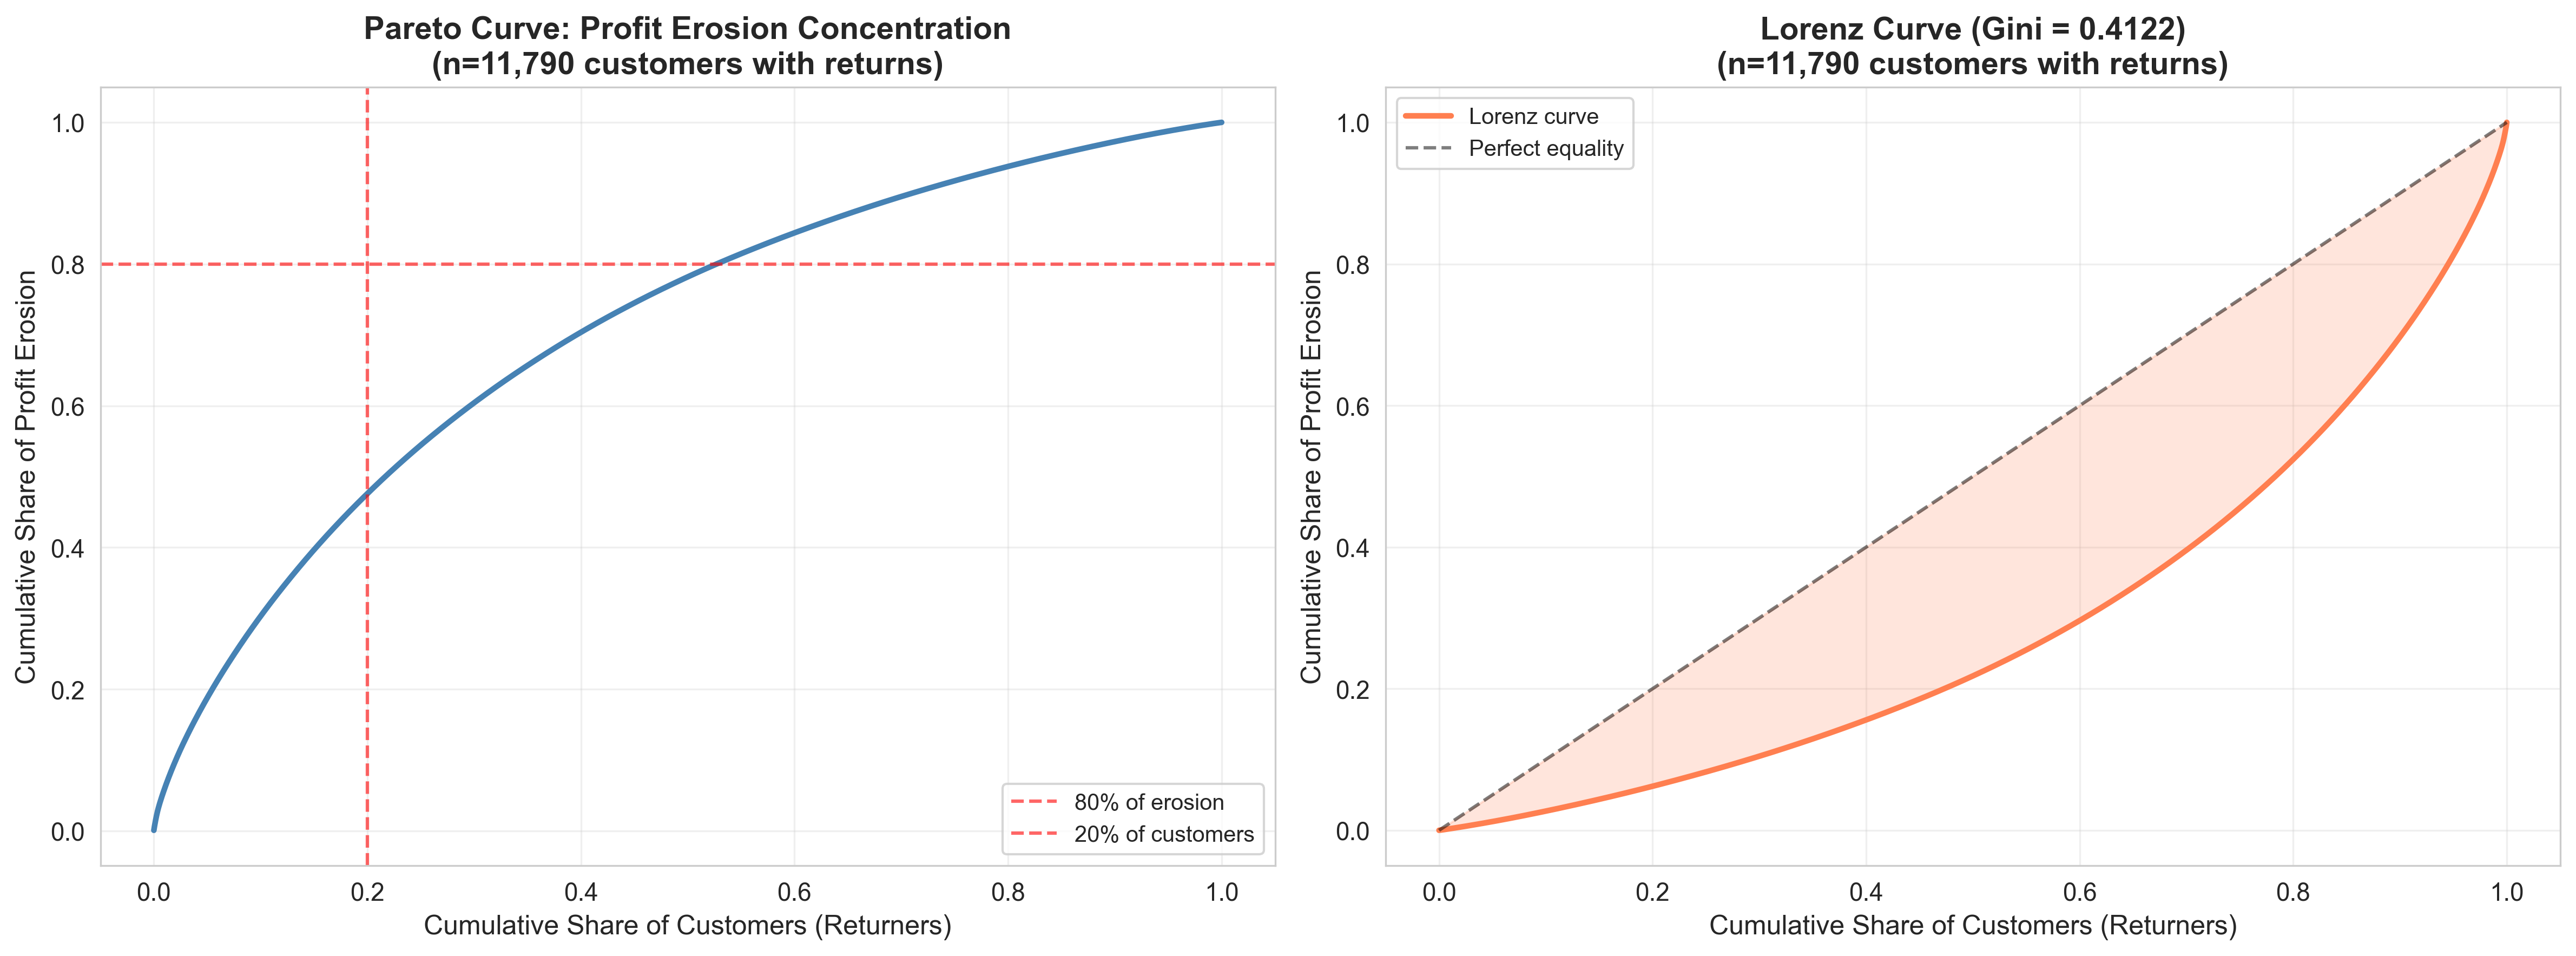

In [24]:
from IPython.display import Image, display

# Display concentration curves
print('\n' + '='*70)
print('CONCENTRATION ANALYSIS VISUALIZATIONS')
print('='*70)
display(Image(filename=str(fig_dir / 'concentration_curves.png')))


CLUSTERING DIAGNOSTICS


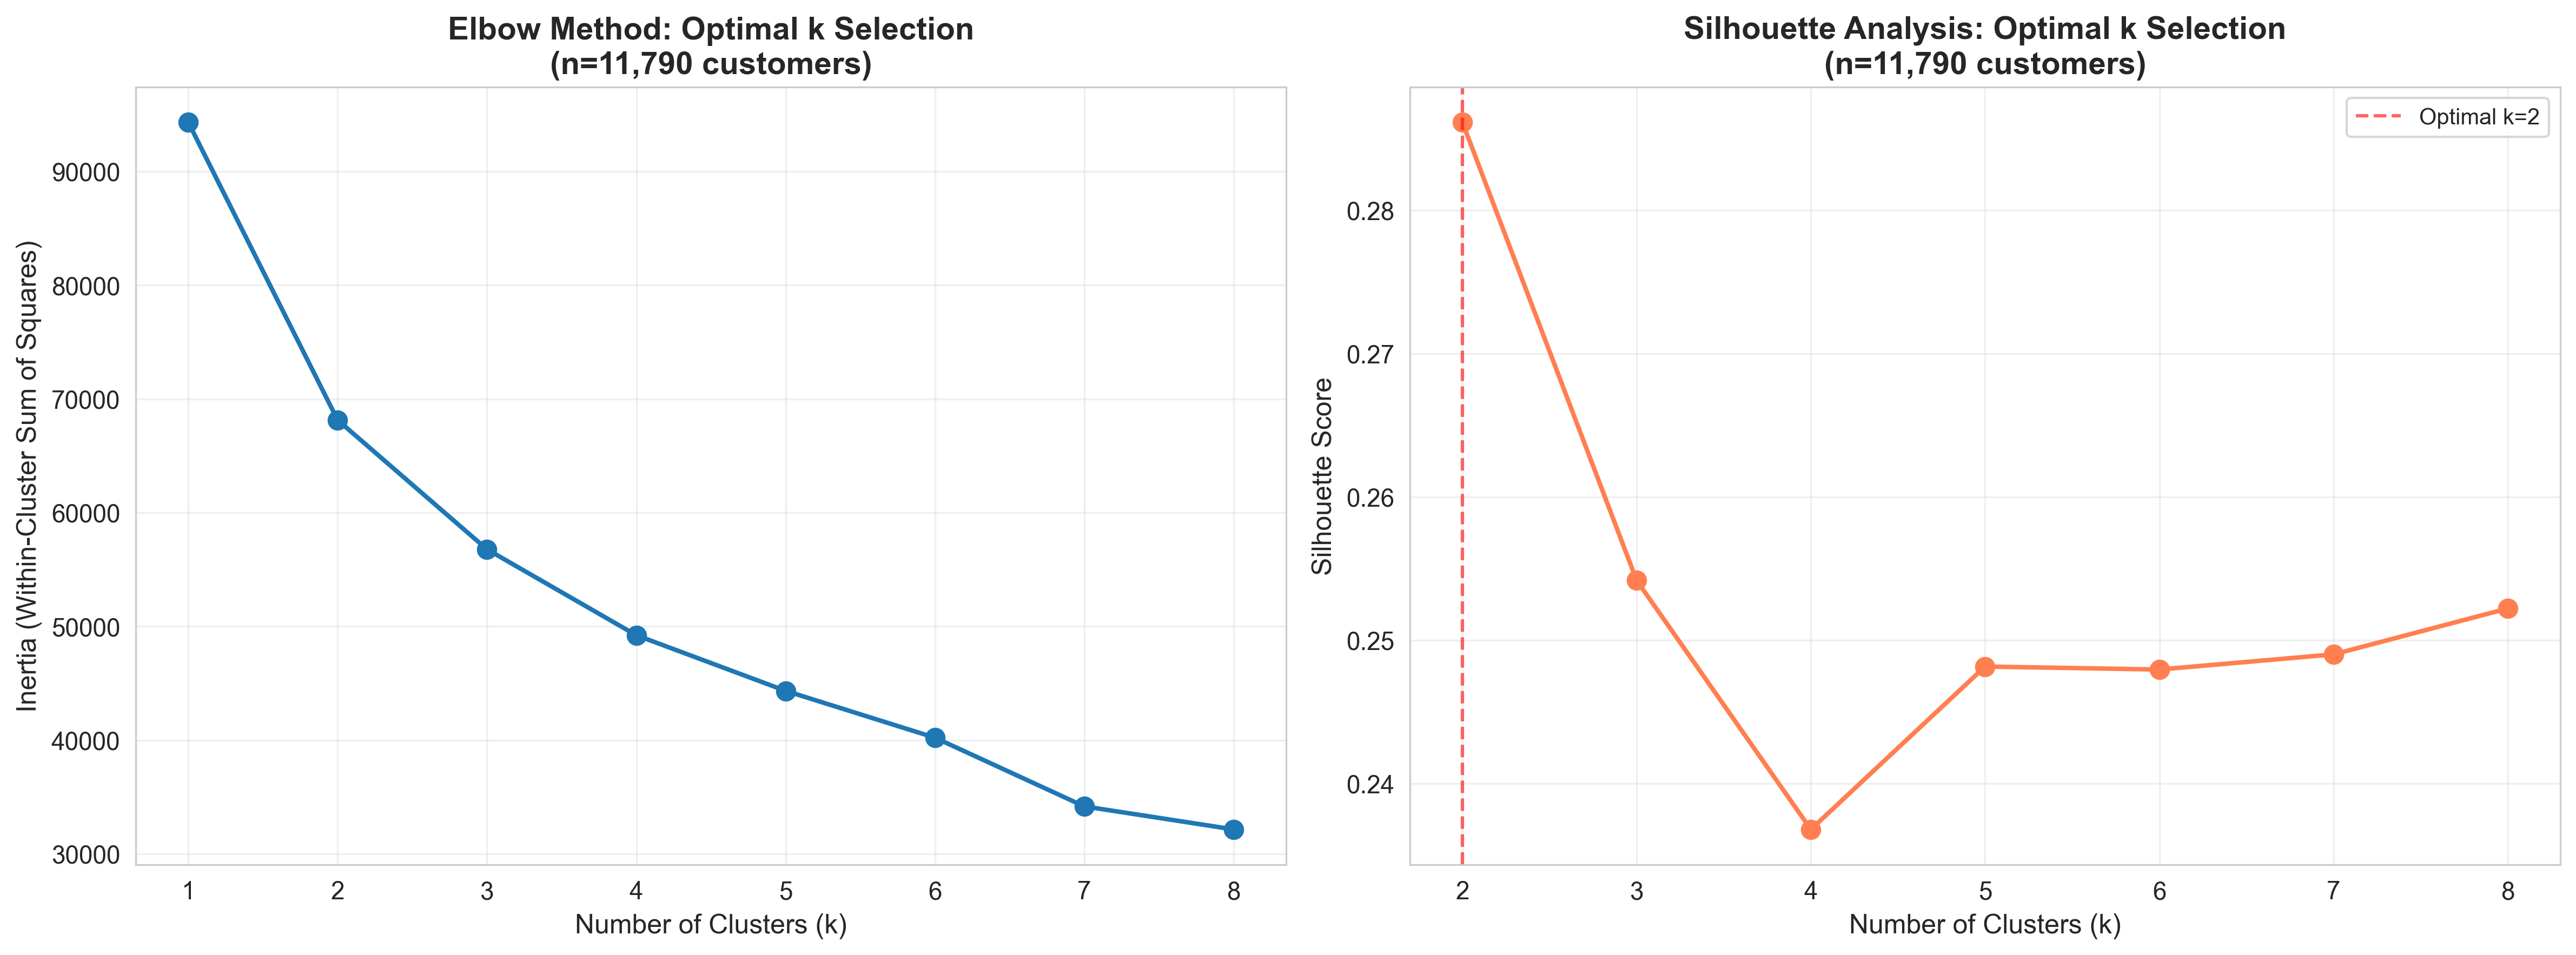

In [25]:
# Display clustering diagnostics
print('\n' + '='*70)
print('CLUSTERING DIAGNOSTICS')
print('='*70)
display(Image(filename=str(fig_dir / 'clustering_diagnostics.png')))


CLUSTER PROFILES


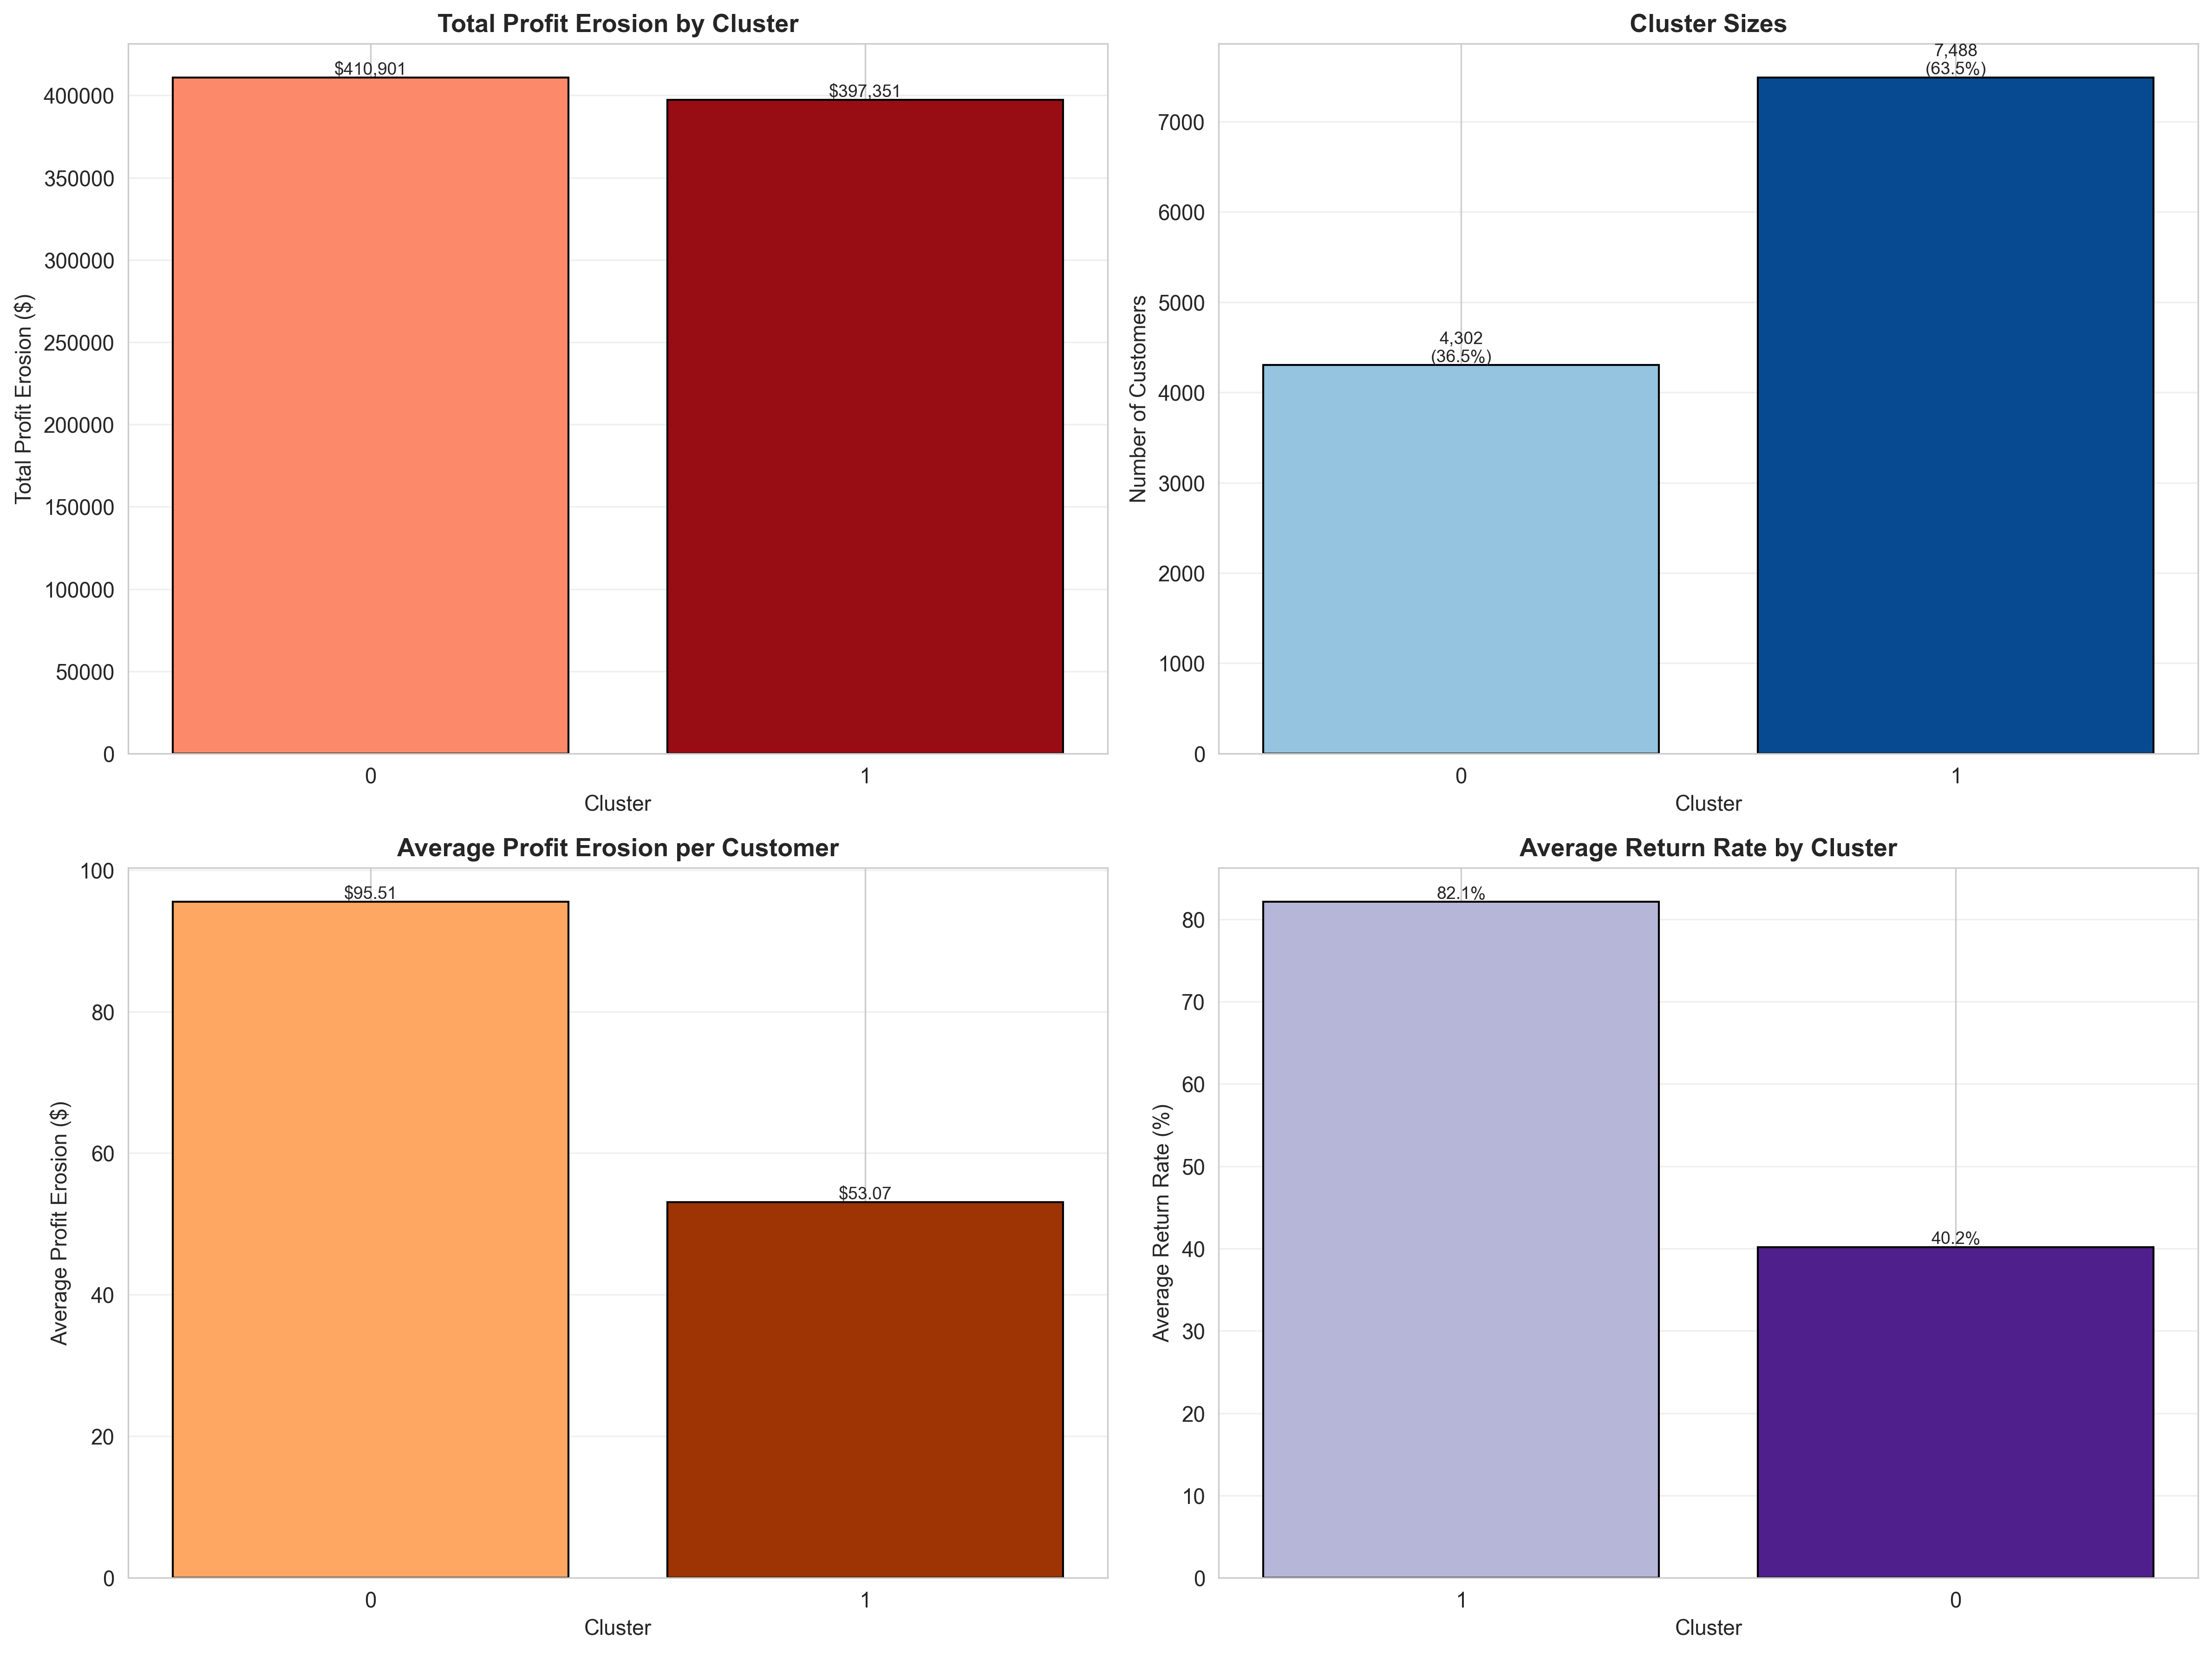

In [26]:
# Display cluster profiles
print('\n' + '='*70)
print('CLUSTER PROFILES')
print('='*70)
display(Image(filename=str(fig_dir / 'cluster_profiles.png')))